In [81]:
from shapely import Polygon, Point, MultiPolygon
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker
from geopandas import GeoDataFrame
import yaml


from shapely.ops import unary_union
from pyproj import Transformer

In [5]:
uk_bfc = gpd.read_file(r"C:\Users\Michał\Downloads\Counties_and_Unitary_Authorities_December_2025_Boundaries_UK_BFC_-8663202655227290036\CTYUA_DEC_2025_UK_BFC.shp")
uk_bfc.columns

Index(['CTYUA25CD', 'CTYUA25NM', 'CTYUA25NMW', 'BNG_E', 'BNG_N', 'LONG', 'LAT',
       'GlobalID', 'geometry'],
      dtype='str')

In [80]:
uk_bfc

,CTYUA25CD,CTYUA25NM,CTYUA25NMW,BNG_E,BNG_N,LONG,LAT,GlobalID,geometry
0,E06000001,Hartlepool,NaN,447161,531473,-1.27017,54.6761,46cfb103-2fb7-4a21-87c8-af09fd669678,"MULTIPOLYGON (((450154.599 525938.201, 450140...."
1,E06000002,Middlesbrough,NaN,451141,516887,-1.21100,54.5447,89cf085d-aacd-4f21-81c4-3aae2195895d,"MULTIPOLYGON (((446854.7 517192.7, 446854.281 ..."
2,E06000003,Redcar and Cleveland,NaN,464330,519596,-1.00656,54.5675,ff7acb00-ff60-4097-807f-679ca750b1b9,"MULTIPOLYGON (((451747.397 520561.1, 451792.20..."
3,E06000004,Stockton-on-Tees,NaN,444940,518179,-1.30665,54.5569,dbaa427f-df7c-4e1d-847e-228ce3b06653,"MULTIPOLYGON (((447177.704 517811.797, 447176...."
4,E06000005,Darlington,NaN,428029,515648,-1.56836,54.5353,13b115c2-63c7-44a9-9b81-6a64bde626c2,"POLYGON ((423496.602 524724.299, 423497.204 52..."
...,...,...,...,...,...,...,...,...,...
213,W06000020,Torfaen,Torfaen,327459,200480,-3.05102,51.6984,f04ced4d-bdfb-4d7b-941b-e2d18d40f572,"POLYGON ((323898.201 211287.499, 324115.698 21..."
214,W06000021,Monmouthshire,Sir Fynwy,337812,209231,-2.90281,51.7783,d9f8fa76-34af-40e1-809c-577a74636caa,"MULTIPOLYGON (((345897.698 180999.599, 345884...."
215,W06000022,Newport,Casnewydd,337897,187432,-2.89769,51.5823,32c4f889-78b8-432f-bd89-603683f90722,"MULTIPOLYGON (((334186.001 192669.398, 334201...."
216,W06000023,Powys,Powys,302329,273254,-3.43532,52.3486,18f67724-d110-4c73-bd7b-0b989a7e444f,"POLYGON ((322392.901 334017.198, 322378.002 33..."


Found 1 row(s) for London.
Total areas extracted (London + surroundings): 13
MULTIPOLYGON (((450154.59949999955 525938.2011999991, 450140.0987 525924.6542000007, 450140.5999999996 525925.8000000007, 450143 525930.3000000007, 450146.7000000002 525935.3000000007, 450150 525938.8000000007, 450154 525941.8000000007, 450158 525944.1999999993, 450160.4000000004 525945, 450163 525945.4000000004, 450165.1964999996 525945.2863999996, 450156.80090000015 525940.2006000001, 450154.59949999955 525938.2011999991)), ((451948.9000000004 532774.75, 451947.5499999998 532774.6500000004, 451946.2000000002 532774.75, 451945.7999999998 532774.8499999996, 451944.6500000004 532775.1999999993, 451943.5999999996 532775.6999999993, 451942.6500000004 532776.3499999996, 451941.75 532777.0999999996, 451940.9500000002 532778, 451940.4500000002 532778.6500000004, 451939.9500000002 532779.75, 451939.5999999996 532780.8499999996, 451939.3499999996 532782.0500000007, 451939.25 532783.25, 451939.2000000002 532784.4499999

AttributeError: 'MultiPolygon' object has no attribute 'plot'

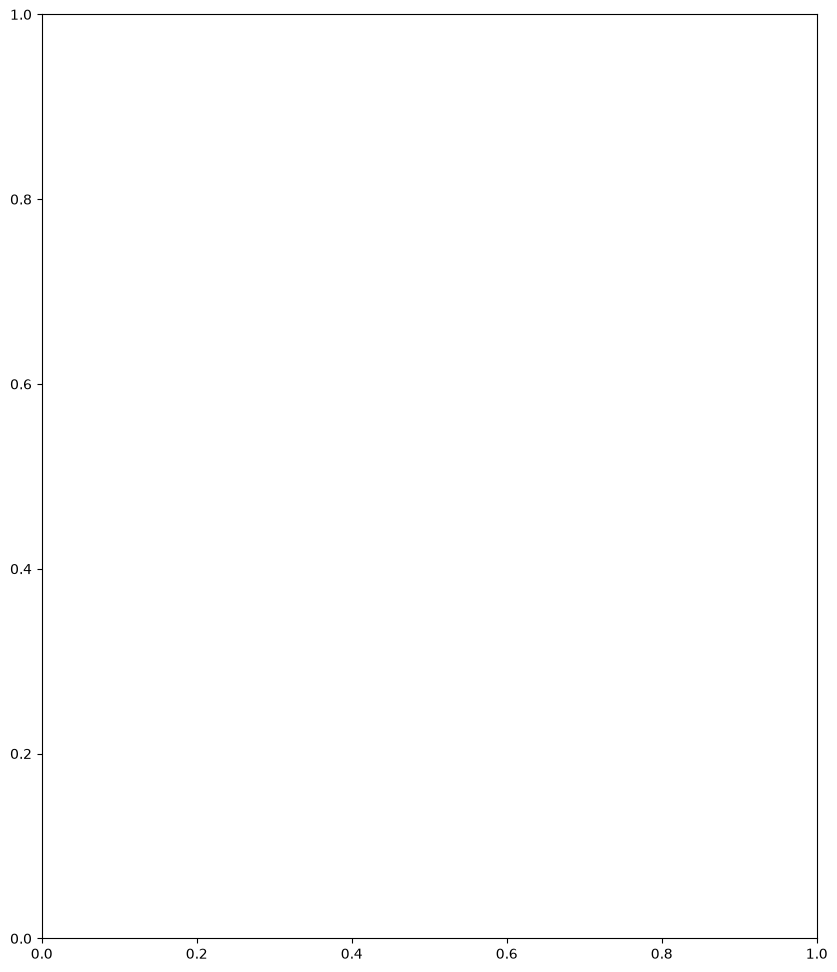

In [42]:
# Common ONS name columns: 'CTYUA24NM', 'LAD24NM', 'NAME', 'CTRY24NM'
name_col = 'CTYUA25NM' 

# 3. Find London (case-insensitive, catches "Greater London", "Inner London", etc.)
london_mask = uk_bfc[name_col].str.contains('Birmingham', case=False, na=False)
london = uk_bfc[london_mask]

if london.empty:
    print(f"Could not find 'London' in column '{name_col}'. Available names:")
    print(uk_bfc[name_col].unique()[:20])  # Show first 20 names to help you
    exit()
else:
    print(f"Found {len(london)} row(s) for London.")

# 4. Combine all London polygons into a single geometry (in case it's split)
london_geom = london.geometry.union_all()

# 5. Buffer London by 10,000 meters (10 km) to catch surrounding areas
# You can adjust this: 5000 = 5km, 20000 = 20km
buffer_distance = 20000  # 10 km
london_buffer = london_geom.buffer(buffer_distance)

# 6. Select all polygons that intersect this buffer (London + neighbors)
surrounding = uk_bfc[uk_bfc.intersects(london_buffer)]
#ix = surrounding[name_col].isin(['Hertfordshire', 'Essex', 'Kent', 'Surrey'])
#surrounding = surrounding[~ix]

print(f"Total areas extracted (London + surroundings): {len(surrounding)}")

# 7. (Optional) If you want to EXCLUDE London itself and just see neighbors:
# surrounding = uk_bfc[(uk_bfc.intersects(london_buffer)) & (~uk_bfc.intersects(london_geom))]

# 8. Plot the result
fig, ax = plt.subplots(figsize=(10, 12))

# Plot all of UK faintly in grey for context
#uk_bfc.plot(ax=ax, color='lightgrey', edgecolor='none', alpha=0.5)

# Plot the extracted London + surroundings in blue
#surrounding.plot(ax=ax, color='lightblue', edgecolor='black', linewidth=0.5)
#uk_bfc.plot(ax=ax, color='lightblue', edgecolor='black', linewidth=0.5)

# Plot London itself in a standout color (e.g., red)
df_plot = uk_bfc['geometry'].iloc[0]
print(df_plot)
df_plot.plot(ax=ax, color='red', edgecolor='black', linewidth=0.8)
#london.plot(ax=ax, color='red', edgecolor='black', linewidth=0.8)

ax.set_title(f'London and Surrounding Areas (Buffer: {buffer_distance/1000} km)')
ax.set_axis_off()
plt.show()

POLYGON ((450140.5999999996 525925.8000000007, 450143 525930.3000000007, 450146.7000000002 525935.3000000007, 450150 525938.8000000007, 450154 525941.8000000007, 450158 525944.1999999993, 450160.4000000004 525945, 450163 525945.4000000004, 450165.1964999996 525945.2863999996, 450156.80090000015 525940.2006000001, 450154.59949999955 525938.2011999991, 450140.0987 525924.6542000007, 450140.5999999996 525925.8000000007))
POLYGON ((447233.6958999997 537035.1046999991, 447243.20249999966 537047.6011999995, 447246.0965 537052.5997000001, 447255.9988000002 537102.1954999994, 447259.09889999963 537108.8036000002, 447263.60080000013 537113.8022000007, 447266.1979 537115.6017000005, 447273.19799999986 537118.6008000001, 447280.70100000035 537120.1004000008, 447289.3005999997 537119.6006000005, 447332.29860000033 537111.5029000007, 447359.59800000023 537102.3955000006, 447378.0998999998 537095.0976, 447391.0033999998 537082.9011000004, 447434.6032999996 537034.5048999991, 447438.7011000002 537030

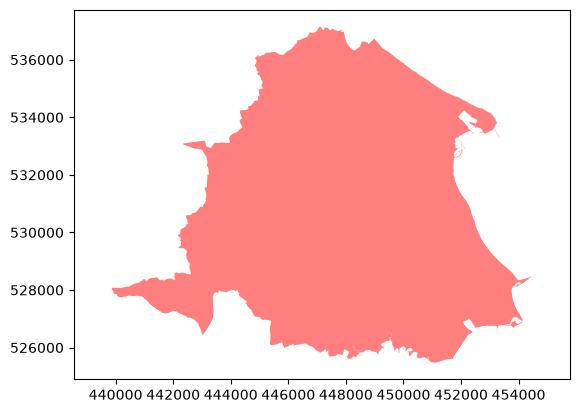

In [52]:
fig, axs = plt.subplots()
axs.set_aspect('equal', 'datalim')

df2 = unary_union(df_plot)

for geom in df2.geoms:    
    print(geom)
    xs, ys = geom.exterior.xy    
    axs.fill(xs, ys, alpha=0.5, fc='r', ec='none')

plt.show()

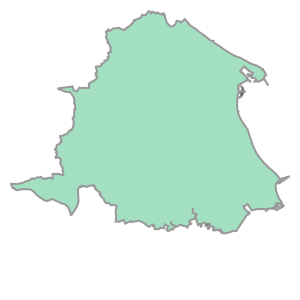

In [56]:
df2

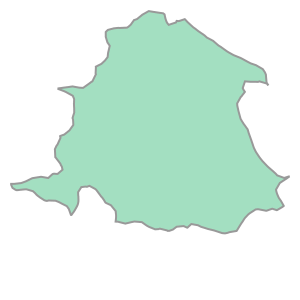

In [65]:
import shapely
type(df2)
sp = shapely.concave_hull(df2, ratio=0.05)
sp

In [ ]:
uk_bfc2 = uk_bfc['geometry'].apply(lambda g: shapely.concave_hull(g, ratio=0.05))

In [74]:
import pandas as pd

In [75]:
uk_bfc2 = uk_bfc2.to_crs(epsg=4326)
uk_bfc3 = pd.DataFrame(uk_bfc2.apply(lambda x: [[round(float(i), 3) for i in nested] for nested in list(x.exterior.coords)]))
uk_bfc3['len'] = uk_bfc3['geometry'].apply(lambda x: len(x))

In [78]:
uk_bfc3.sort_values('len', ascending=False)

,geometry,len
163,"[[-5.854, 54.636], [-5.848, 54.64], [-5.848, 5...",1717
153,"[[-6.481, 54.776], [-6.478, 54.781], [-6.464, ...",1587
193,"[[-4.536, 56.794], [-4.529, 56.801], [-4.521, ...",1489
181,"[[-4.813, 56.417], [-4.812, 56.418], [-4.812, ...",1368
61,"[[-2.304, 54.426], [-2.293, 54.439], [-2.268, ...",1356
...,...,...
36,"[[-0.66, 51.528], [-0.66, 51.528], [-0.654, 51...",355
210,"[[-3.59, 51.757], [-3.59, 51.757], [-3.586, 51...",336
209,"[[-3.343, 51.534], [-3.342, 51.535], [-3.341, ...",332
217,"[[-3.445, 51.816], [-3.445, 51.816], [-3.445, ...",312


In [17]:
london_coords = london.to_crs(epsg=4326)
[[round(float(i), 3) for i in nested] for nested in list(london_coords['geometry'].values[0].exterior.coords)]

[[-0.08, 51.507],
 [-0.109, 51.51],
 [-0.111, 51.51],
 [-0.112, 51.515],
 [-0.105, 51.519],
 [-0.085, 51.52],
 [-0.079, 51.522],
 [-0.08, 51.507]]

In [120]:
def multipoly_to_poly(mpoly: MultiPolygon, ratio:float = 0.05) -> Polygon:
    if isinstance(mpoly, Polygon):
        return mpoly
    
    if isinstance(mpoly, MultiPolygon):
        return shapely.concave_hull(df2, ratio=ratio)

    return None

def poly_to_coordinates(poly: Polygon, prec:int = 3) -> list[list]:
    return [[round(float(i), prec) for i in nested] for nested in list(poly.exterior.coords)]

class IndentedDumper(yaml.Dumper):
    def increase_indent(self, flow=False, indentless=False):
        return super(IndentedDumper, self).increase_indent()

gdf = gpd.read_file(r"C:\Users\Michał\Downloads\Counties_and_Unitary_Authorities_December_2025_Boundaries_UK_BFC_-8663202655227290036\CTYUA_DEC_2025_UK_BFC.shp")
name_col = 'CTYUA25NM'
gdf = gdf[[name_col, 'geometry']]
gdf['geometry'] = gdf['geometry'].apply(multipoly_to_poly)
gdf = gdf.to_crs(epsg=4326)

for _, row in gdf.iterrows():
    f_name = fr"D:\projects\street-level-crime-pipeline\config\uk_crime_api\areas\{row[name_col].replace(' ', '_').lower()}.yml"
    area_name = row[name_col]
    #poly = multipoly_to_poly(row['geometry'])
    coordinates = poly_to_coordinates(row['geometry'])
    
    with open(f_name, "w") as f:
        yaml.dump({"area_name": area_name,"coordinates": coordinates}, f, default_flow_style=None, Dumper=IndentedDumper, indent=2)

In [100]:
gdf = gpd.read_file(r"C:\Users\Michał\Downloads\Counties_and_Unitary_Authorities_December_2025_Boundaries_UK_BFC_-8663202655227290036\CTYUA_DEC_2025_UK_BFC.shp")
gdf.to_crs(epsg=4326)

,CTYUA25CD,CTYUA25NM,CTYUA25NMW,BNG_E,BNG_N,LONG,LAT,GlobalID,geometry
0,E06000001,Hartlepool,NaN,447161,531473,-1.27017,54.6761,46cfb103-2fb7-4a21-87c8-af09fd669678,"MULTIPOLYGON (((-1.22469 54.6261, -1.22491 54...."
1,E06000002,Middlesbrough,NaN,451141,516887,-1.21100,54.5447,89cf085d-aacd-4f21-81c4-3aae2195895d,"MULTIPOLYGON (((-1.27719 54.54783, -1.27719 54..."
2,E06000003,Redcar and Cleveland,NaN,464330,519596,-1.00656,54.5675,ff7acb00-ff60-4097-807f-679ca750b1b9,"MULTIPOLYGON (((-1.20097 54.57762, -1.20029 54..."
3,E06000004,Stockton-on-Tees,NaN,444940,518179,-1.30665,54.5569,dbaa427f-df7c-4e1d-847e-228ce3b06653,"MULTIPOLYGON (((-1.27209 54.55336, -1.27211 54..."
4,E06000005,Darlington,NaN,428029,515648,-1.56836,54.5353,13b115c2-63c7-44a9-9b81-6a64bde626c2,"POLYGON ((-1.63767 54.61713, -1.63766 54.61669..."
...,...,...,...,...,...,...,...,...,...
213,W06000020,Torfaen,Torfaen,327459,200480,-3.05102,51.6984,f04ced4d-bdfb-4d7b-941b-e2d18d40f572,"POLYGON ((-3.10489 51.79504, -3.10171 51.79372..."
214,W06000021,Monmouthshire,Sir Fynwy,337812,209231,-2.90281,51.7783,d9f8fa76-34af-40e1-809c-577a74636caa,"MULTIPOLYGON (((-2.78124 51.5253, -2.78142 51...."
215,W06000022,Newport,Casnewydd,337897,187432,-2.89769,51.5823,32c4f889-78b8-432f-bd89-603683f90722,"MULTIPOLYGON (((-2.95222 51.62897, -2.95199 51..."
216,W06000023,Powys,Powys,302329,273254,-3.43532,52.3486,18f67724-d110-4c73-bd7b-0b989a7e444f,"POLYGON ((-3.15512 52.89797, -3.15533 52.89756..."


In [64]:
surrounding.to_file("london_and_surrounding.shp")

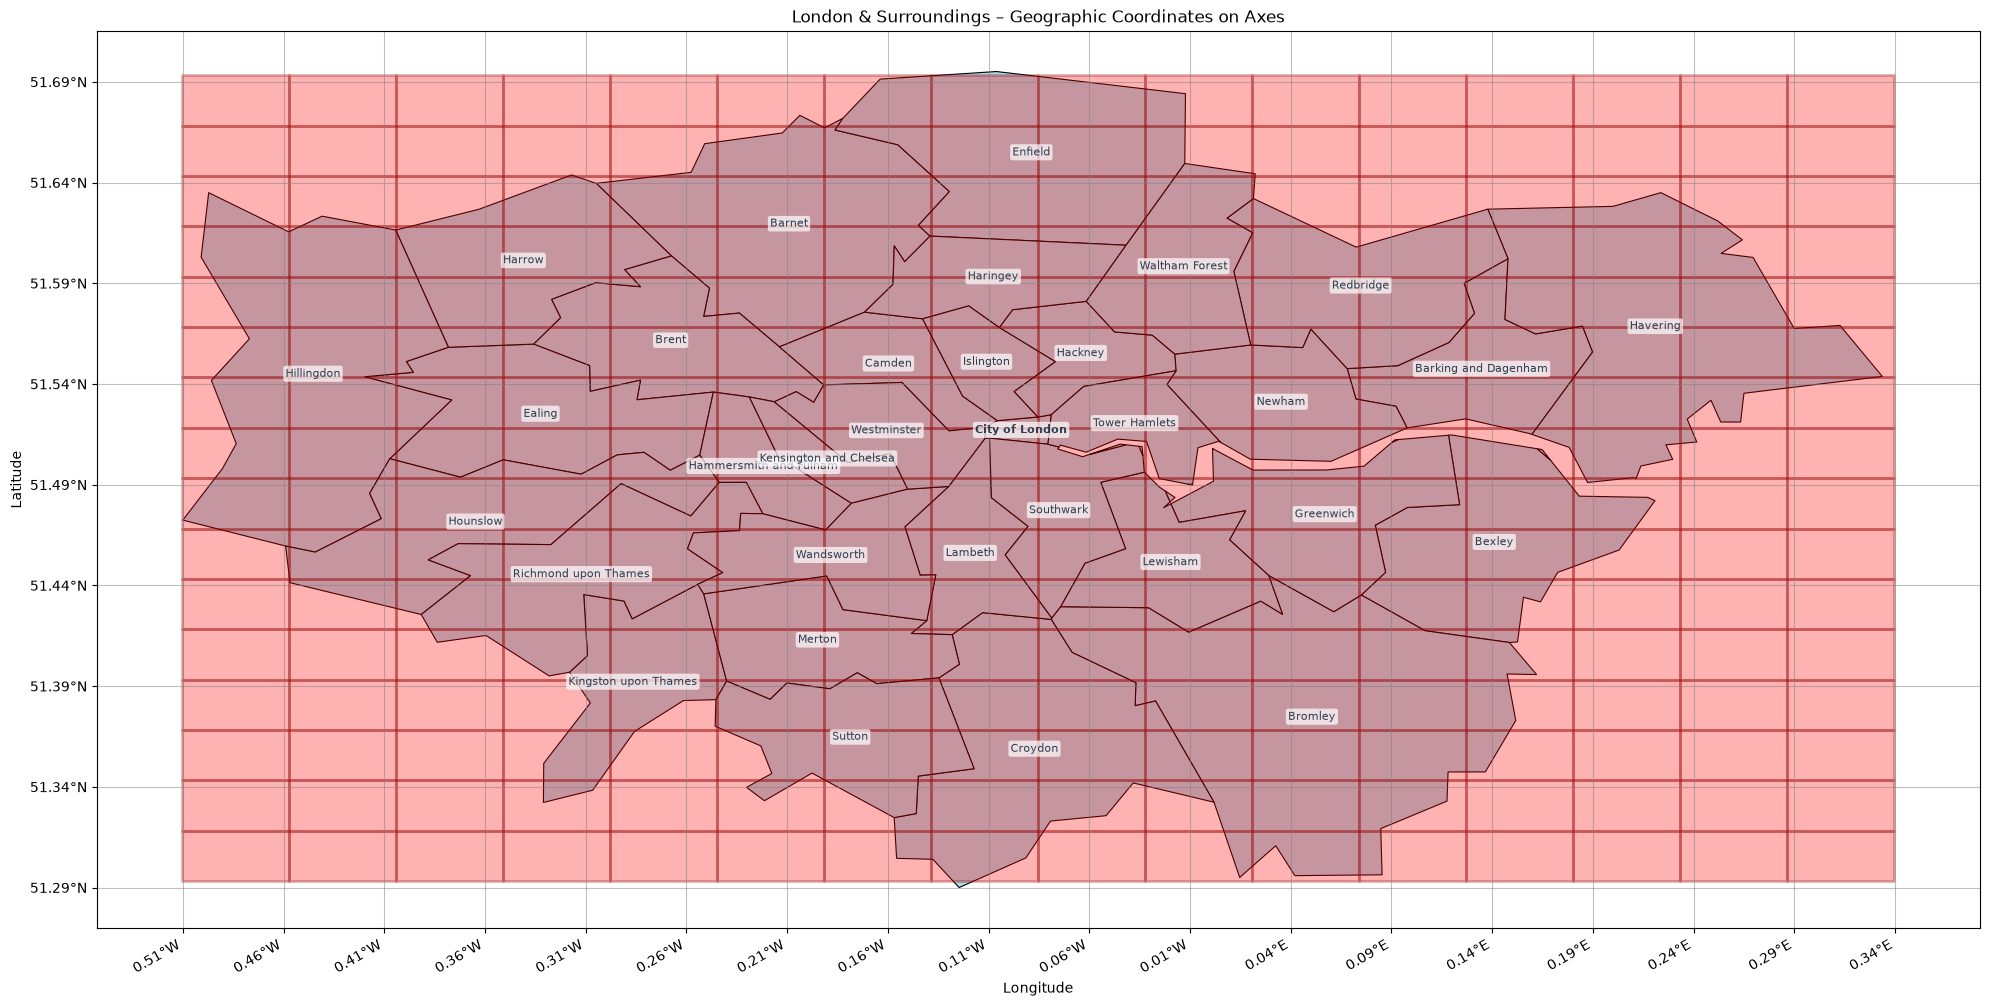

In [166]:
# Format the labels with degree symbols and direction (E/W, N/S)
def format_lon(lon):
    return f'{abs(lon):.2f}°W' if lon < 0 else f'{lon:.2f}°E'

def format_lat(lat):
    return f'{lat:.2f}°S' if lat < 0 else f'{lat:.2f}°N' 

uk_bfc = gpd.read_file(r"C:\Users\Michał\Downloads\Counties_and_Unitary_Authorities_December_2021_EN_BUC_2462994983727268841\CTYUA_DEC_2021_EN_BUC.shp")
uk_bfc = uk_bfc.to_crs(epsg=4326)
name_col = 'CTYUA21NM'

# Find London (case-insensitive, catches "Greater London", "Inner London", etc.)
london_mask = uk_bfc[name_col].str.contains('London', case=False, na=False)
london = uk_bfc[london_mask]

# Combine all of london shapes 
london_geom = london.geometry.union_all()

# Buffer in degrees
buffer_distance = 0.3
london_buffer = london_geom.buffer(buffer_distance)

# Select all polygons that intersect this buffer and remove what's not needed
surrounding = uk_bfc[uk_bfc.intersects(london_buffer)]
ix = surrounding[name_col].isin(['Hertfordshire', 'Essex', 'Kent', 'Surrey', 'Thurrock'])
surrounding = surrounding[~ix]

# --- Plot ---
fig, ax = plt.subplots(figsize=(20, 20))

# Plot all of UK faintly in grey for context
#uk_bfc.plot(ax=ax, color='lightgrey', edgecolor='none', alpha=0.5)

# Plot the main data
surrounding.plot(ax=ax, color='lightblue', edgecolor='black', linewidth=0.8)

# --- Add Grid ---
ax.grid(True, which='major', linestyle='-', linewidth=0.8, color='grey', alpha=0.5)
ax.grid(True, which='minor', linestyle='--', linewidth=0.5, color='lightgrey', alpha=0.3)

# --- Add Labels for ALL areas (centroids) ---
for idx, row in surrounding.iterrows():
    # Get the centroid of the polygon
    centroid = row.geometry.centroid
    # Get the name 
    label = row[name_col]
    
    # Adjust font size based on the area size (optional)
    # Larger areas = bigger labels
    area = row.geometry.area
    fontsize = 8 if area < 1e8 else 10  # tweak based on your data scale
    
    # Plot the label
    ax.text(centroid.x, centroid.y, label, 
            fontsize=fontsize, 
            ha='center', va='center', 
            fontweight='bold' if 'London' in str(label) else 'normal',
            color='#2C3E50',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7, edgecolor='none'))

# --- Set tick intervals based on your data extent ---
# Get the bounds (xmin, ymin, xmax, ymax) in the map's CRS (EPSG:27700)
bounds = surrounding.total_bounds  # returns (minx, miny, maxx, maxy)

# Calculate tick spacing
x_range = bounds[2] - bounds[0]
y_range = bounds[3] - bounds[1]
tick_spacing = 0.05

# Create tick positions
x_ticks = np.arange(bounds[0], bounds[2] + tick_spacing, tick_spacing)
y_ticks = np.arange(bounds[1], bounds[3] + tick_spacing, tick_spacing)
ax.set_xticks(x_ticks)
ax.tick_params(axis='x', rotation=30, rotation_mode='xtick')
ax.set_yticks(y_ticks)

ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: format_lon(x)))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: format_lat(x)))

# --- Axis labels ---
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('London & Surroundings – Geographic Coordinates on Axes')

polygon_latlon = Polygon([
    (-0.51, 51.29),  # lon, lat
    (-0.51, 51.69),
    (0.34, 51.69),
    (0.34, 51.29)
])

# --- 3. Convert to a GeoDataFrame with CRS EPSG:4326 (WGS84) ---
gdf_poly = gpd.GeoDataFrame(
    {'geometry': [polygon_latlon]},
    crs='EPSG:4326'
)

    # --- 5. Plot your map and overlay the custom polygon ---
#fig, ax = plt.subplots(figsize=(12, 14))

#gdf_poxly.plot(
grid_box.plot(
    ax=ax,
    color='red',
    alpha=0.3,          # semi-transparent fill
    edgecolor='darkred',
    linewidth=2,
    label='Custom Polygon'
)

plt.tight_layout()
plt.show()
